# DeepLabV3+ Dental Segmentation: Baseline, Fine-Tuning, and Modified-Loss Training

This notebook builds a complete **semantic segmentation** pipeline for your dental dataset using **DeepLabV3+**.

## Scenarios
1. **Baseline**: evaluate the raw DeepLabV3+ model **without training**
2. **Fine-tuning**: train DeepLabV3+ with a standard segmentation loss
3. **Modified loss**: train DeepLabV3+ with a custom loss designed for segmentation imbalance

## Dataset
Images:
- `/content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DentalDatasetsReady_512`

Masks:
- `/content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DentalDatasetsReady_512_mask`

Both folders are expected to contain:
- `train/`
- `valid/`
- `test/`

## Notes
- The pipeline assumes **binary segmentation**
- It is robust to masks stored as either `0/1` or `0/255`
- The code uses **PyTorch + segmentation_models_pytorch**

## Loss Options for Scenario 3

Below are good options for the **modified loss** experiment:

1. **Dice + BCE**  
   Stable and usually the safest first choice for binary medical-style segmentation.

2. **Tversky Loss**  
   Useful when false positives and false negatives need different penalties.

3. **Focal + Dice**  
   Good when foreground pixels are very sparse and the dataset is highly imbalanced.

This notebook uses **Dice + BCE** as the default modified-loss scenario because it is a strong and practical default for binary segmentation.

In [1]:
!pip -q install segmentation-models-pytorch albumentations opencv-python matplotlib pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00


In [2]:
import os
import gc
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Configuration
SEED = 42

IMAGE_ROOT = Path("/content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DentalDatasetsReady_512")
MASK_ROOT  = Path("/content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DentalDatasetsReady_512_mask")

SPLITS = ["train", "valid", "test"]

# Model / training config
ENCODER_NAME = "resnet34"          # lightweight and good for Colab
ENCODER_WEIGHTS = "imagenet"
IN_CHANNELS = 3
NUM_CLASSES = 1

IMAGE_SIZE = 512
BATCH_SIZE = 64
NUM_WORKERS = 4

FINE_TUNE_EPOCHS = 15
MOD_LOSS_EPOCHS = 15

FINE_TUNE_LR = 1e-4
MOD_LOSS_LR = 1e-4
WEIGHT_DECAY = 1e-4

THRESHOLD = 0.5
AMP_ENABLED = True

OUTPUT_DIR = Path("/content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+


In [5]:
# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA L4


In [6]:
# Basic dataset checks
for split in SPLITS:
    img_dir = IMAGE_ROOT / split
    msk_dir = MASK_ROOT / split

    assert img_dir.exists(), f"Image split not found: {img_dir}"
    assert msk_dir.exists(), f"Mask split not found: {msk_dir}"

    img_files = sorted(list(img_dir.glob("*.jpg"))) + sorted(list(img_dir.glob("*.jpeg"))) + sorted(list(img_dir.glob("*.png")))
    mask_files = sorted(list(msk_dir.glob("*.png")))

    print(f"{split:>5} | images: {len(img_files):4d} | masks: {len(mask_files):4d}")

print("\nDataset path validation passed.")

train | images: 4772 | masks: 4772
valid | images: 2071 | masks: 2071
 test | images: 1345 | masks: 1345

Dataset path validation passed.


In [7]:
# Dataset class
class DentalSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transforms=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transforms = transforms

        self.image_paths = sorted(
            list(self.image_dir.glob("*.jpg")) +
            list(self.image_dir.glob("*.jpeg")) +
            list(self.image_dir.glob("*.png"))
        )

        if len(self.image_paths) == 0:
            raise ValueError(f"No image files found in {self.image_dir}")

        self.samples = []
        missing_masks = []

        for img_path in self.image_paths:
            mask_path = self.mask_dir / f"{img_path.stem}.png"
            if mask_path.exists():
                self.samples.append((img_path, mask_path))
            else:
                missing_masks.append(mask_path.name)

        if len(missing_masks) > 0:
            raise ValueError(
                f"Found {len(missing_masks)} images without matching masks in {self.mask_dir}. "
                f"Examples: {missing_masks[:5]}"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if image is None:
            raise ValueError(f"Failed to read image: {img_path}")

        if image.ndim == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Failed to read mask: {mask_path}")

        # Robust binarization for either 0/1 or 0/255 masks
        mask = (mask > 0).astype(np.float32)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).float()

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask, img_path.name

In [8]:
# Albumentations transforms
def get_train_transforms(image_size=512):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_valid_transforms(image_size=512):
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [9]:
# Datasets and loaders
train_dataset = DentalSegmentationDataset(
    image_dir=IMAGE_ROOT / "train",
    mask_dir=MASK_ROOT / "train",
    transforms=get_train_transforms(IMAGE_SIZE),
)

valid_dataset = DentalSegmentationDataset(
    image_dir=IMAGE_ROOT / "valid",
    mask_dir=MASK_ROOT / "valid",
    transforms=get_valid_transforms(IMAGE_SIZE),
)

test_dataset = DentalSegmentationDataset(
    image_dir=IMAGE_ROOT / "test",
    mask_dir=MASK_ROOT / "test",
    transforms=get_valid_transforms(IMAGE_SIZE),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))
print("Test  samples:", len(test_dataset))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train samples: 4772
Valid samples: 2071
Test  samples: 1345


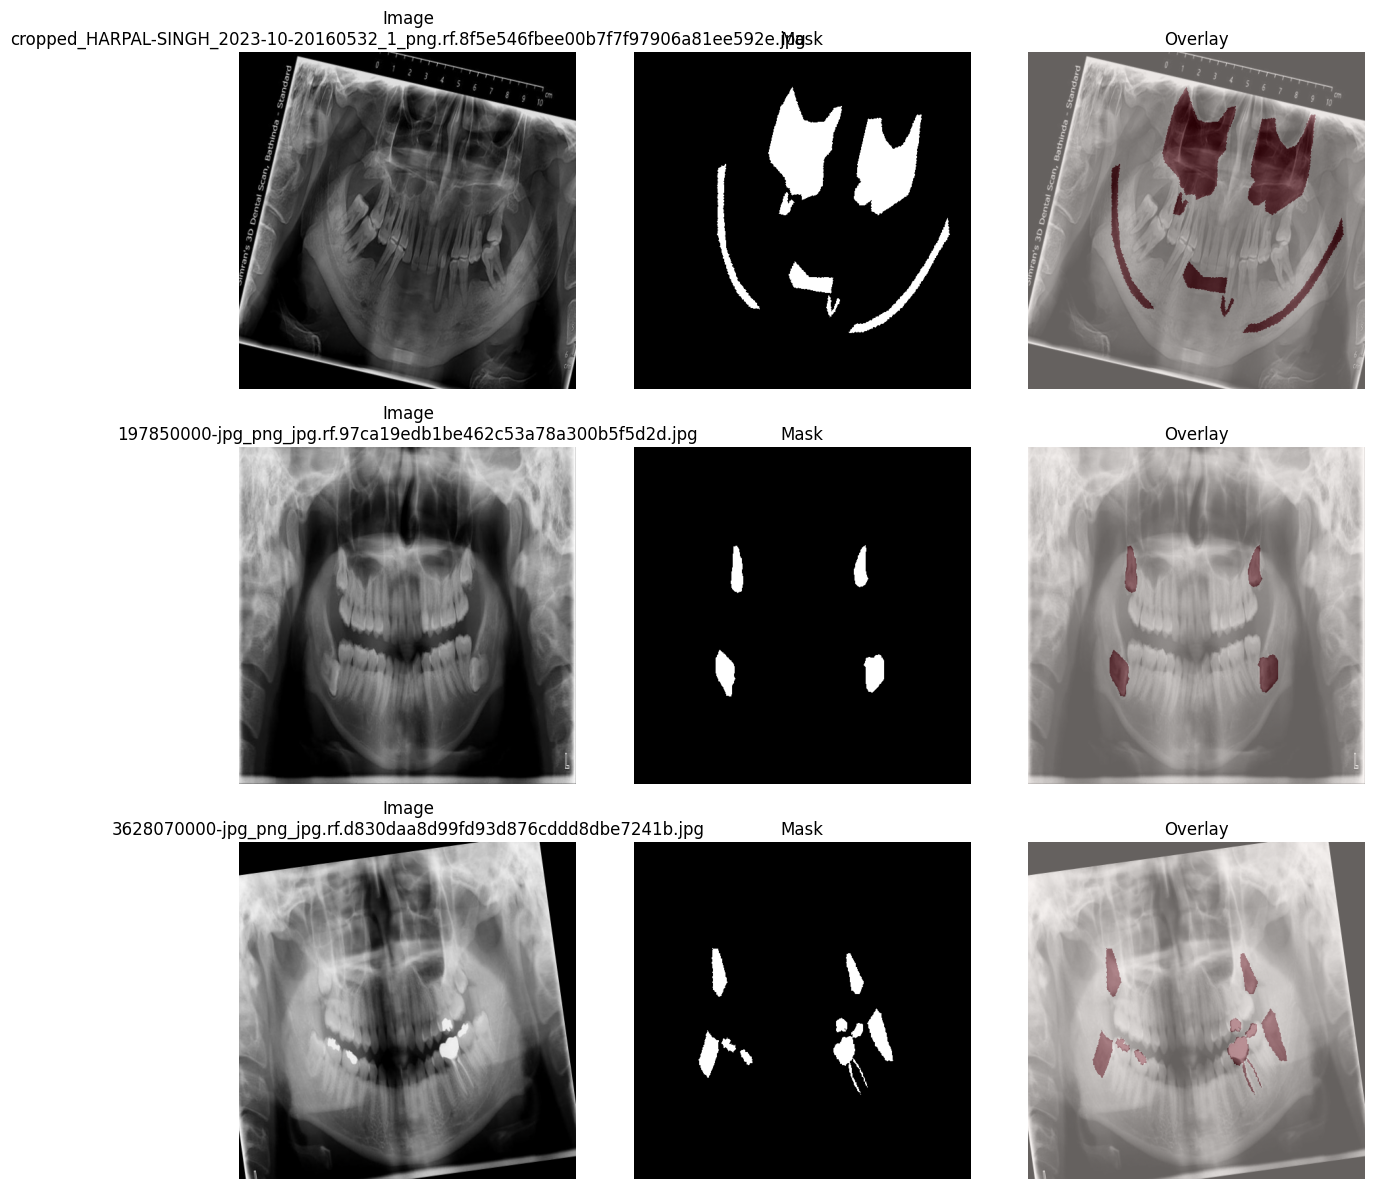

In [10]:
# Visualize a few training samples
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(3, 1, 1)
    image = tensor * std + mean
    return image.clamp(0, 1)

batch = next(iter(train_loader))
images, masks, names = batch

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    img = denormalize_image(images[i]).permute(1, 2, 0).cpu().numpy()
    msk = masks[i, 0].cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image\n{names[i]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(msk, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img)
    axes[i, 2].imshow(msk, alpha=0.4, cmap="Reds")
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Model builder
def build_model():
    model = smp.DeepLabV3Plus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        activation=None,
    )
    return model

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

temp_model = build_model()
total_params, trainable_params = count_parameters(temp_model)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del temp_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Total parameters:     22,437,457
Trainable parameters: 22,437,457


In [12]:
# Loss functions
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce = smp.losses.SoftBCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        bce_loss = self.bce(logits, targets)
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

def get_loss(loss_name="bce"):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    elif loss_name == "dice_bce":
        return DiceBCELoss(dice_weight=0.5, bce_weight=0.5)
    elif loss_name == "tversky":
        return smp.losses.TverskyLoss(mode="binary", from_logits=True, alpha=0.3, beta=0.7)
    else:
        raise ValueError(f"Unsupported loss_name: {loss_name}")

In [13]:
# Metrics
@torch.no_grad()
def compute_batch_confusion(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = (targets > 0.5).float()

    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()
    tn = ((1 - preds) * (1 - targets)).sum()
    return tp, fp, fn, tn

def compute_metrics_from_confusion(tp, fp, fn, tn, eps=1e-7):
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    specificity = tn / (tn + fp + eps)

    return {
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
        "accuracy": float(accuracy),
        "specificity": float(specificity),
    }

In [14]:
# Train / validate loops
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, threshold=0.5):
    model.train()
    running_loss = 0.0

    total_tp = torch.tensor(0.0, device=device)
    total_fp = torch.tensor(0.0, device=device)
    total_fn = torch.tensor(0.0, device=device)
    total_tn = torch.tensor(0.0, device=device)

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, masks, _ in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            logits = model(images)
            loss = criterion(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        tp, fp, fn, tn = compute_batch_confusion(logits.detach(), masks, threshold=threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics_from_confusion(total_tp, total_fp, total_fn, total_tn)
    metrics["loss"] = epoch_loss
    return metrics

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0

    total_tp = torch.tensor(0.0, device=device)
    total_fp = torch.tensor(0.0, device=device)
    total_fn = torch.tensor(0.0, device=device)
    total_tn = torch.tensor(0.0, device=device)

    pbar = tqdm(loader, desc="Valid", leave=False)
    for images, masks, _ in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        running_loss += loss.item() * images.size(0)

        tp, fp, fn, tn = compute_batch_confusion(logits, masks, threshold=threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics_from_confusion(total_tp, total_fp, total_fn, total_tn)
    metrics["loss"] = epoch_loss
    return metrics

In [15]:
# Full training runner
def run_training_experiment(
    experiment_name,
    loss_name,
    epochs,
    lr,
    weight_decay,
    threshold=0.5
):
    model = build_model().to(device)
    criterion = get_loss(loss_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    save_dir = OUTPUT_DIR / experiment_name
    save_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = save_dir / "best_model.pth"
    history_csv_path = save_dir / "history.csv"

    history = []
    best_dice = -1.0

    print(f"\n{'='*90}")
    print(f"Experiment: {experiment_name}")
    print(f"Loss:       {loss_name}")
    print(f"Epochs:     {epochs}")
    print(f"LR:         {lr}")
    print(f"{'='*90}")

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            scaler=scaler,
            threshold=threshold,
        )

        valid_metrics = validate_one_epoch(
            model=model,
            loader=valid_loader,
            criterion=criterion,
            device=device,
            threshold=threshold,
        )

        scheduler.step(valid_metrics["dice"])
        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "valid_loss": valid_metrics["loss"],
            "valid_iou": valid_metrics["iou"],
            "valid_dice": valid_metrics["dice"],
            "valid_precision": valid_metrics["precision"],
            "valid_recall": valid_metrics["recall"],
            "valid_accuracy": valid_metrics["accuracy"],
            "valid_specificity": valid_metrics["specificity"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(
            f"[Epoch {epoch:02d}/{epochs:02d}] "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"train_dice={train_metrics['dice']:.4f} | "
            f"valid_loss={valid_metrics['loss']:.4f} | "
            f"valid_dice={valid_metrics['dice']:.4f} | "
            f"valid_iou={valid_metrics['iou']:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        if valid_metrics["dice"] > best_dice:
            best_dice = valid_metrics["dice"]
            torch.save(model.state_dict(), best_model_path)
            print(f"  -> Saved new best model to: {best_model_path}")

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_csv_path, index=False)
    print(f"History saved to: {history_csv_path}")
    print(f"Best validation Dice: {best_dice:.4f}")

    return {
        "model": model,
        "history": history_df,
        "best_model_path": best_model_path,
        "save_dir": save_dir,
        "best_valid_dice": best_dice,
    }

In [16]:
# Evaluation helper
@torch.no_grad()
def evaluate_model(model, loader, criterion, device, threshold=0.5, split_name="test"):
    model.eval()

    running_loss = 0.0
    total_tp = torch.tensor(0.0, device=device)
    total_fp = torch.tensor(0.0, device=device)
    total_fn = torch.tensor(0.0, device=device)
    total_tn = torch.tensor(0.0, device=device)

    for images, masks, _ in tqdm(loader, desc=f"Evaluate-{split_name}", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        running_loss += loss.item() * images.size(0)

        tp, fp, fn, tn = compute_batch_confusion(logits, masks, threshold=threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    metrics = compute_metrics_from_confusion(total_tp, total_fp, total_fn, total_tn)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics

In [17]:
# Visualization helper
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=5, threshold=0.5, title="Predictions"):
    model.eval()
    indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        image, mask, name = dataset[idx]
        image_input = image.unsqueeze(0).to(device)

        logits = model(image_input)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_vis = denormalize_image(image).permute(1, 2, 0).cpu().numpy()
        mask_vis = mask[0].cpu().numpy()

        axes[row, 0].imshow(image_vis)
        axes[row, 0].set_title(f"Image\n{name}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask_vis, cmap="gray")
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(prob, cmap="viridis")
        axes[row, 2].set_title("Predicted Probability")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(image_vis)
        axes[row, 3].imshow(pred, alpha=0.4, cmap="Reds")
        axes[row, 3].set_title("Predicted Mask Overlay")
        axes[row, 3].axis("off")

    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

Evaluate-valid-baseline:   0%|          | 0/33 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1b19467560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1b19467560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Evaluate-test-baseline:   0%|          | 0/22 [00:00<?, ?it/s]

Baseline - Validation metrics:
      iou    dice  precision  recall  accuracy  specificity    loss
0  0.0026  0.0051     0.0312  0.0028    0.9768       0.9981  0.6818

Baseline - Test metrics:
      iou    dice  precision  recall  accuracy  specificity    loss
0  0.0022  0.0044       0.03  0.0024    0.9746       0.9981  0.6818


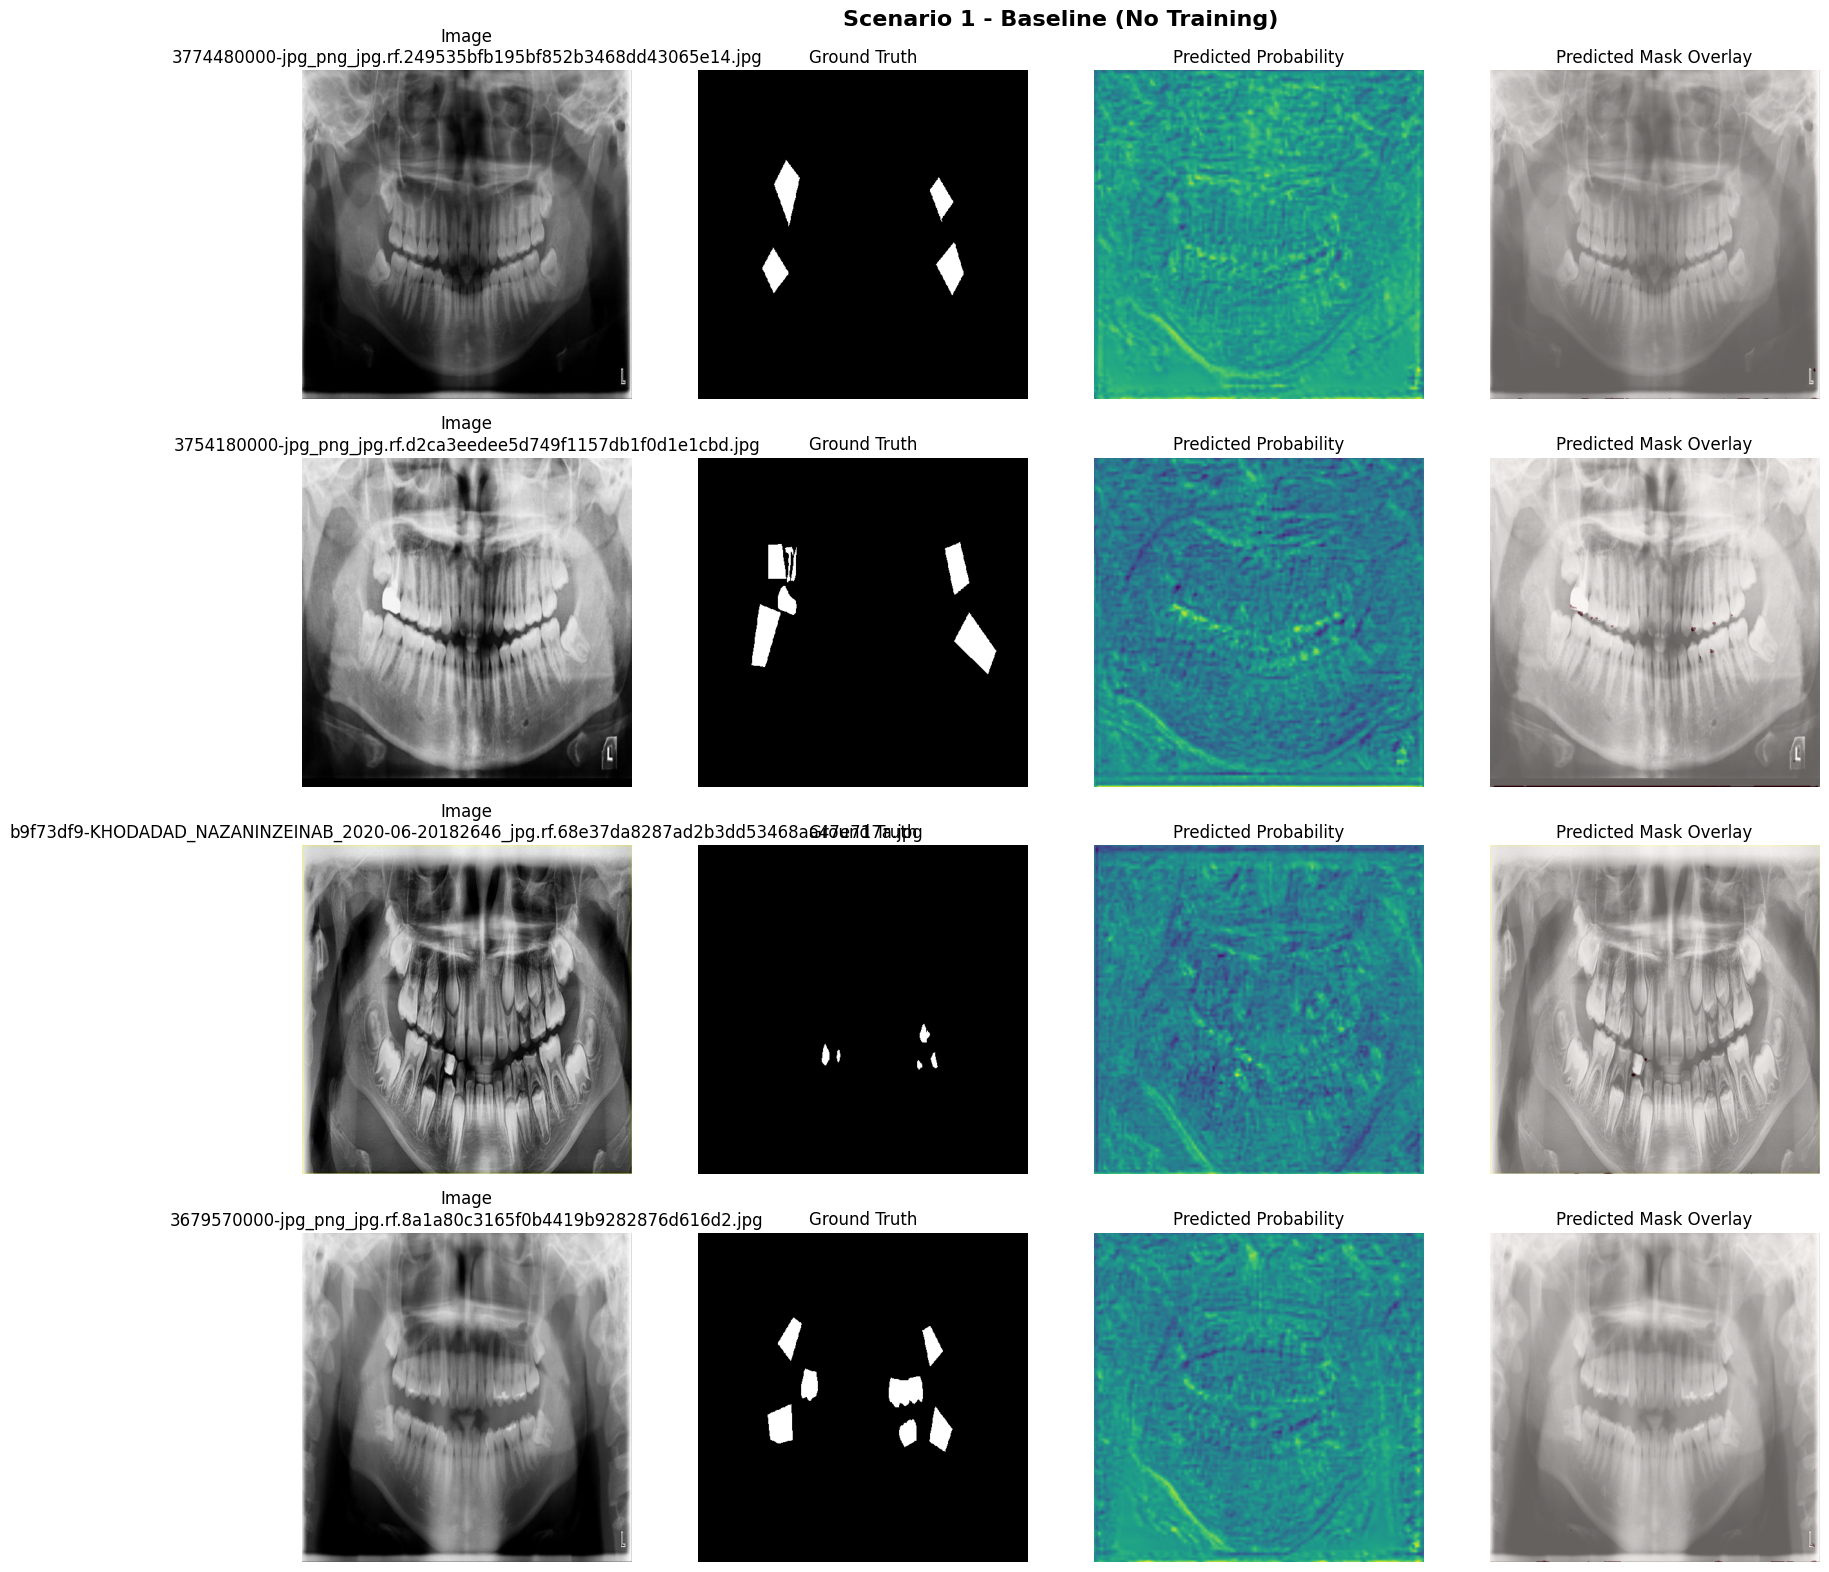

In [19]:
# Scenario 1: Baseline (no training)
baseline_model = build_model().to(device)
baseline_criterion = get_loss("bce")

baseline_valid_metrics = evaluate_model(
    model=baseline_model,
    loader=valid_loader,
    criterion=baseline_criterion,
    device=device,
    threshold=THRESHOLD,
    split_name="valid-baseline",
)

baseline_test_metrics = evaluate_model(
    model=baseline_model,
    loader=test_loader,
    criterion=baseline_criterion,
    device=device,
    threshold=THRESHOLD,
    split_name="test-baseline",
)

print("Baseline - Validation metrics:")
print(pd.DataFrame([baseline_valid_metrics]).round(4))

print("\nBaseline - Test metrics:")
print(pd.DataFrame([baseline_test_metrics]).round(4))

visualize_predictions(
    model=baseline_model,
    dataset=test_dataset,
    device=device,
    num_samples=4,
    threshold=THRESHOLD,
    title="Scenario 1 - Baseline (No Training)"
)

In [18]:
# Scenario 2: Fine-tuning with BCEWithLogitsLoss
fine_tune_result = run_training_experiment(
    experiment_name="scenario_2_finetune_bce",
    loss_name="bce",
    epochs=FINE_TUNE_EPOCHS,
    lr=FINE_TUNE_LR,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
)

fine_tune_history = fine_tune_result["history"]
fine_tune_history.tail()


Experiment: scenario_2_finetune_bce
Loss:       bce
Epochs:     15
LR:         0.0001


Train:   0%|          | 0/75 [00:00<?, ?it/s]

/tmp/ipykernel_3100/3927749538.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Valid:   0%|          | 0/33 [00:00<?, ?it/s]

[Epoch 01/15] train_loss=0.4162 | train_dice=0.0857 | valid_loss=0.2508 | valid_dice=0.0649 | valid_iou=0.0335 | time=808.1s
  -> Saved new best model to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/scenario_2_finetune_bce/best_model.pth


...

[Epoch 14/15] train_loss=0.0437 | train_dice=0.6996 | valid_loss=0.0403 | valid_dice=0.6911 | valid_iou=0.5280 | time=86.5s


Train:   0%|          | 0/75 [00:00<?, ?it/s]

Valid:   0%|          | 0/33 [00:00<?, ?it/s]

[Epoch 15/15] train_loss=0.0419 | train_dice=0.7097 | valid_loss=0.0393 | valid_dice=0.7019 | valid_iou=0.5408 | time=86.2s
History saved to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/scenario_2_finetune_bce/history.csv
Best validation Dice: 0.7038


,epoch,lr,train_loss,train_iou,train_dice,train_precision,train_recall,valid_loss,valid_iou,valid_dice,valid_precision,valid_recall,valid_accuracy,valid_specificity,epoch_time_sec
10,11,0.0001,0.051089,0.500060,0.666720,0.781398,0.581395,0.044481,0.501038,0.667589,0.787261,0.579499,0.987644,0.996574,86.282920
11,12,0.0001,0.048316,0.514475,0.679410,0.791366,0.595206,0.044011,0.535613,0.697589,0.691700,0.703579,0.986939,0.993139,86.450310
12,13,0.0001,0.045968,0.524854,0.688399,0.789205,0.610428,0.040723,0.543024,0.703844,0.776942,0.643318,0.988409,0.995959,85.887741
13,14,0.0001,0.043720,0.538047,0.699650,0.794751,0.624876,0.040282,0.527959,0.691064,0.785463,0.616921,0.988191,0.996313,86.455219
14,15,0.0001,0.041913,0.550004,0.709680,0.800542,0.637342,0.039261,0.540765,0.701944,0.756575,0.654671,0.988097,0.995392,86.235362


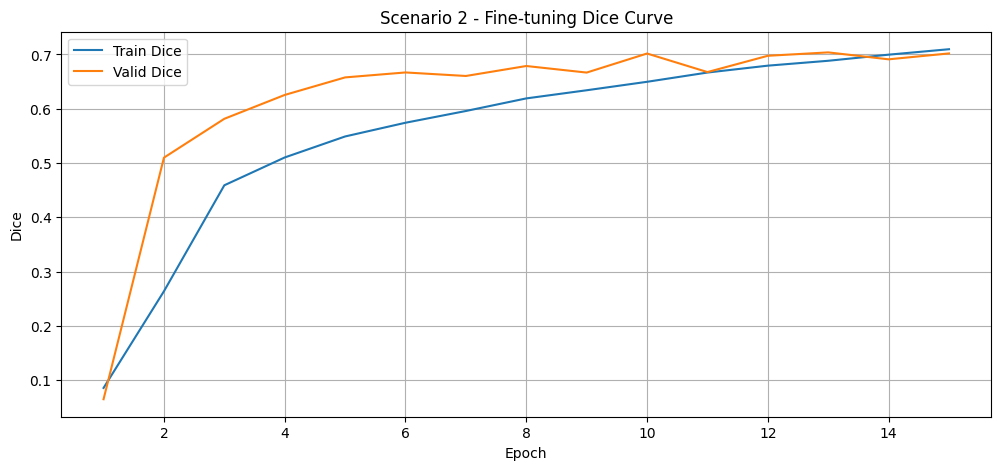

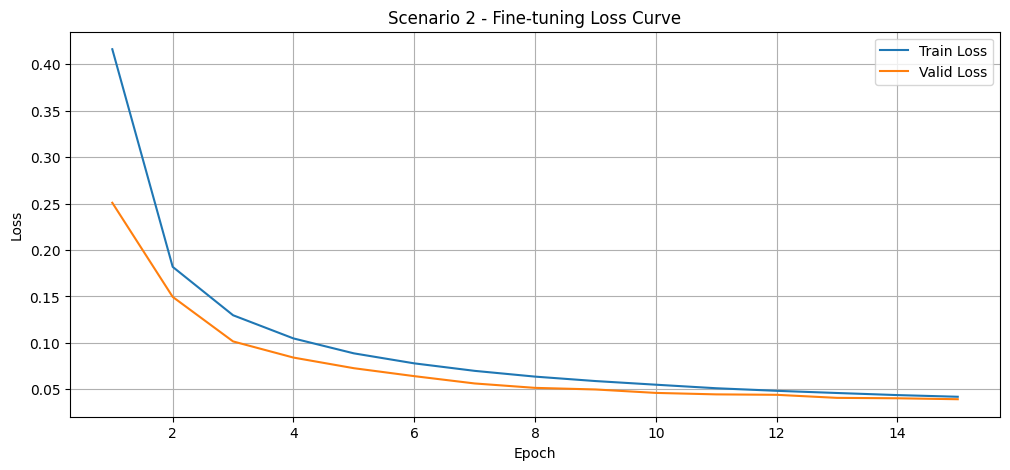

In [20]:
# Plot fine-tuning history
plt.figure(figsize=(12, 5))
plt.plot(fine_tune_history["epoch"], fine_tune_history["train_dice"], label="Train Dice")
plt.plot(fine_tune_history["epoch"], fine_tune_history["valid_dice"], label="Valid Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Scenario 2 - Fine-tuning Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(fine_tune_history["epoch"], fine_tune_history["train_loss"], label="Train Loss")
plt.plot(fine_tune_history["epoch"], fine_tune_history["valid_loss"], label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scenario 2 - Fine-tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Evaluate-valid-finetune:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluate-test-finetune:   0%|          | 0/22 [00:00<?, ?it/s]

Fine-tuned - Validation metrics:
     iou    dice  precision  recall  accuracy  specificity    loss
0  0.543  0.7038     0.7769  0.6433    0.9884        0.996  0.0407

Fine-tuned - Test metrics:
      iou    dice  precision  recall  accuracy  specificity    loss
0  0.5077  0.6735     0.7801  0.5925    0.9865        0.996  0.0452


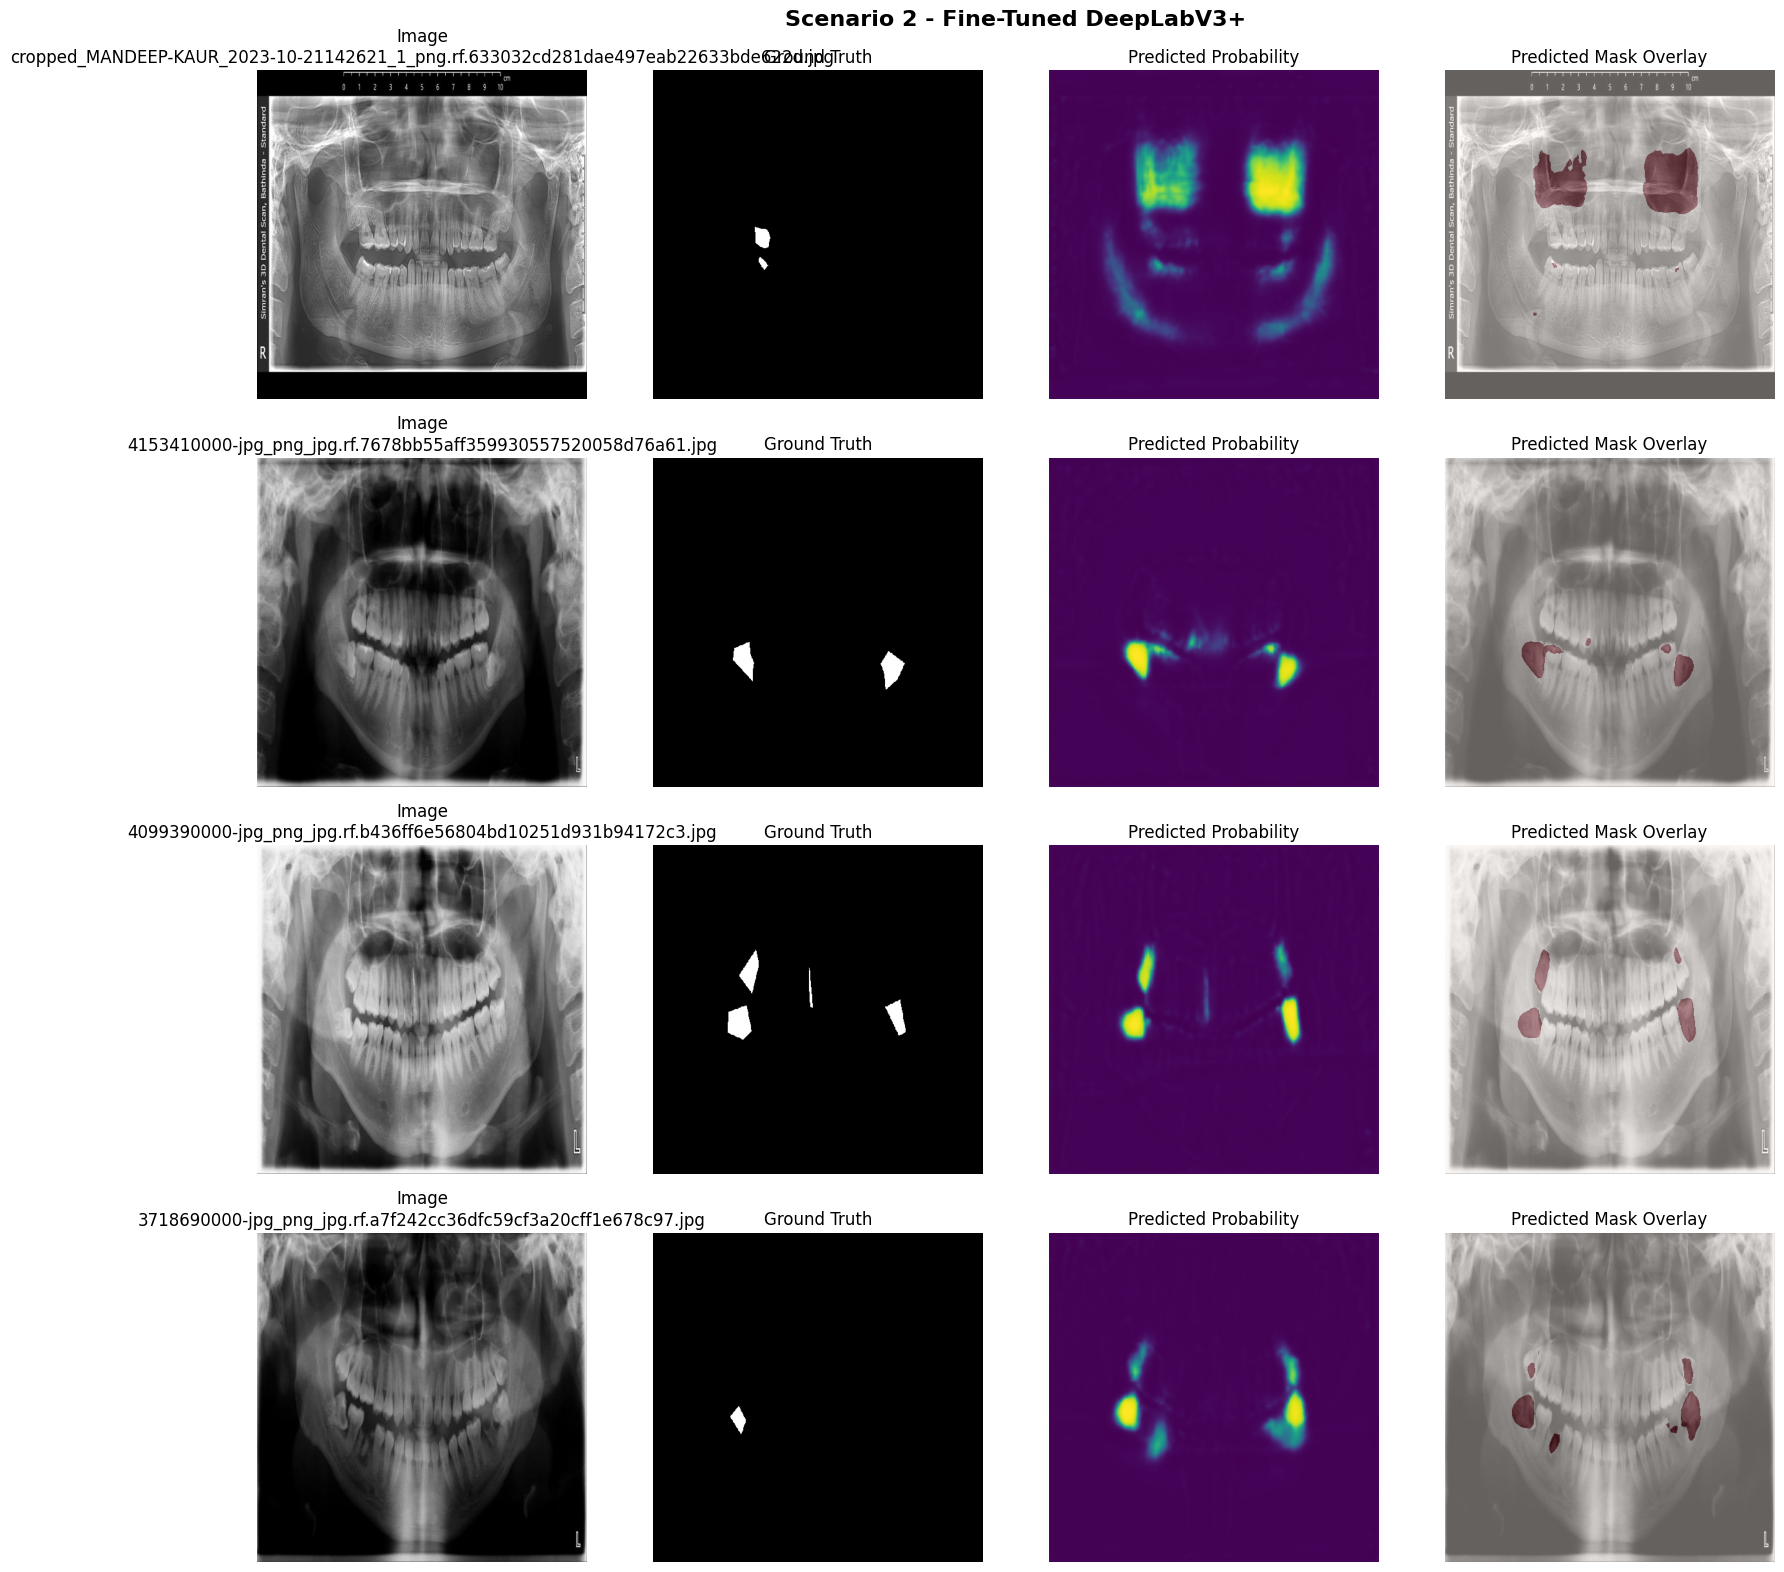

In [21]:
# Load best fine-tuned model and evaluate on test
best_finetune_model = build_model().to(device)
best_finetune_model.load_state_dict(torch.load(fine_tune_result["best_model_path"], map_location=device))

fine_tune_valid_metrics = evaluate_model(
    model=best_finetune_model,
    loader=valid_loader,
    criterion=get_loss("bce"),
    device=device,
    threshold=THRESHOLD,
    split_name="valid-finetune",
)

fine_tune_test_metrics = evaluate_model(
    model=best_finetune_model,
    loader=test_loader,
    criterion=get_loss("bce"),
    device=device,
    threshold=THRESHOLD,
    split_name="test-finetune",
)

print("Fine-tuned - Validation metrics:")
print(pd.DataFrame([fine_tune_valid_metrics]).round(4))

print("\nFine-tuned - Test metrics:")
print(pd.DataFrame([fine_tune_test_metrics]).round(4))

visualize_predictions(
    model=best_finetune_model,
    dataset=test_dataset,
    device=device,
    num_samples=4,
    threshold=THRESHOLD,
    title="Scenario 2 - Fine-Tuned DeepLabV3+"
)

In [22]:
# Scenario 3: Modified loss (Dice + BCE)
modified_loss_result = run_training_experiment(
    experiment_name="scenario_3_modified_dice_bce",
    loss_name="dice_bce",
    epochs=MOD_LOSS_EPOCHS,
    lr=MOD_LOSS_LR,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
)

modified_loss_history = modified_loss_result["history"]
modified_loss_history.tail()


Experiment: scenario_3_modified_dice_bce
Loss:       dice_bce
Epochs:     15
LR:         0.0001


Train:   0%|          | 0/75 [00:00<?, ?it/s]

/tmp/ipykernel_3100/3927749538.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Valid:   0%|          | 0/33 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1b19467560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

Train:   0%|          | 0/75 [00:00<?, ?it/s]

Valid:   0%|          | 0/33 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1b19467560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1b19467560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[Epoch 15/15] train_loss=0.1540 | train_dice=0.7680 | valid_loss=0.1730 | valid_dice=0.7199 | valid_iou=0.5624 | time=91.7s
History saved to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/scenario_3_modified_dice_bce/history.csv
Best validation Dice: 0.7266


,epoch,lr,train_loss,train_iou,train_dice,train_precision,train_recall,valid_loss,valid_iou,valid_dice,valid_precision,valid_recall,valid_accuracy,valid_specificity,epoch_time_sec
10,11,0.00010,0.178265,0.585612,0.738658,0.762862,0.715942,0.177224,0.563842,0.721099,0.757854,0.687744,0.988610,0.995192,89.497005
11,12,0.00010,0.173785,0.589255,0.741549,0.765986,0.718623,0.174034,0.565720,0.722632,0.751083,0.696258,0.988557,0.994952,87.042006
12,13,0.00005,0.165901,0.601562,0.751219,0.770566,0.732820,0.173956,0.565490,0.722444,0.728984,0.716021,0.988221,0.994176,86.217476
13,14,0.00005,0.156741,0.619380,0.764959,0.788715,0.742593,0.169770,0.570658,0.726648,0.746176,0.708117,0.988594,0.994730,87.243619
14,15,0.00005,0.153958,0.623314,0.767953,0.790131,0.746985,0.172977,0.562375,0.719898,0.742576,0.698564,0.988361,0.994702,91.698388


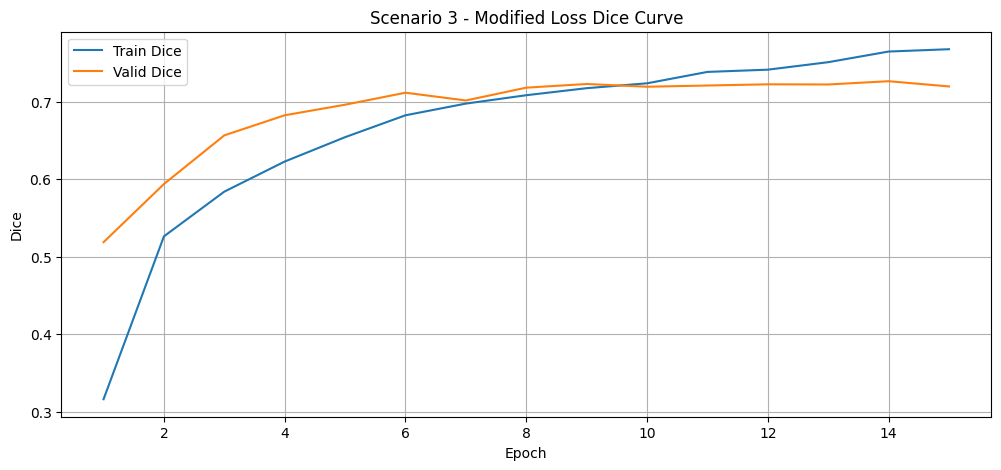

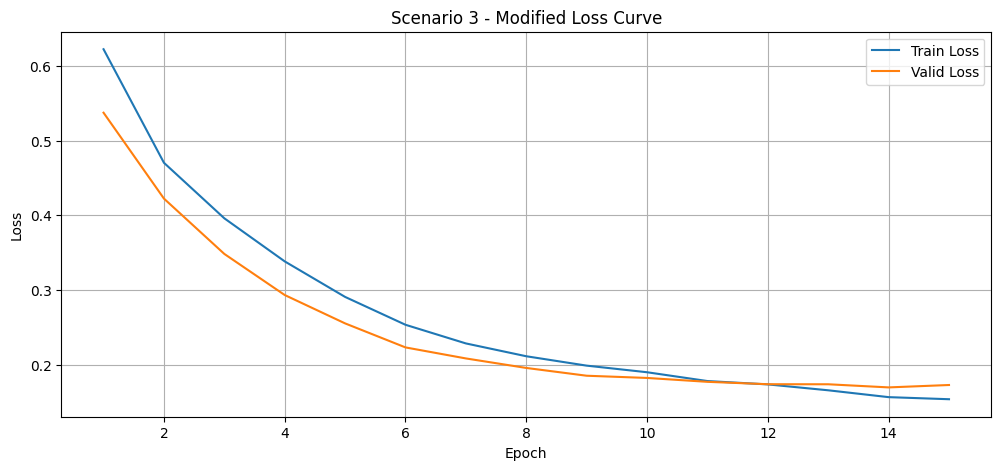

In [23]:
# Plot modified-loss training history
plt.figure(figsize=(12, 5))
plt.plot(modified_loss_history["epoch"], modified_loss_history["train_dice"], label="Train Dice")
plt.plot(modified_loss_history["epoch"], modified_loss_history["valid_dice"], label="Valid Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Scenario 3 - Modified Loss Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(modified_loss_history["epoch"], modified_loss_history["train_loss"], label="Train Loss")
plt.plot(modified_loss_history["epoch"], modified_loss_history["valid_loss"], label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scenario 3 - Modified Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Evaluate-valid-modified:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluate-test-modified:   0%|          | 0/22 [00:00<?, ?it/s]

Modified loss - Validation metrics:
      iou    dice  precision  recall  accuracy  specificity    loss
0  0.5707  0.7266     0.7462  0.7081    0.9886       0.9947  0.1698

Modified loss - Test metrics:
      iou    dice  precision  recall  accuracy  specificity    loss
0  0.5387  0.7002      0.757  0.6513    0.9868       0.9949  0.1895


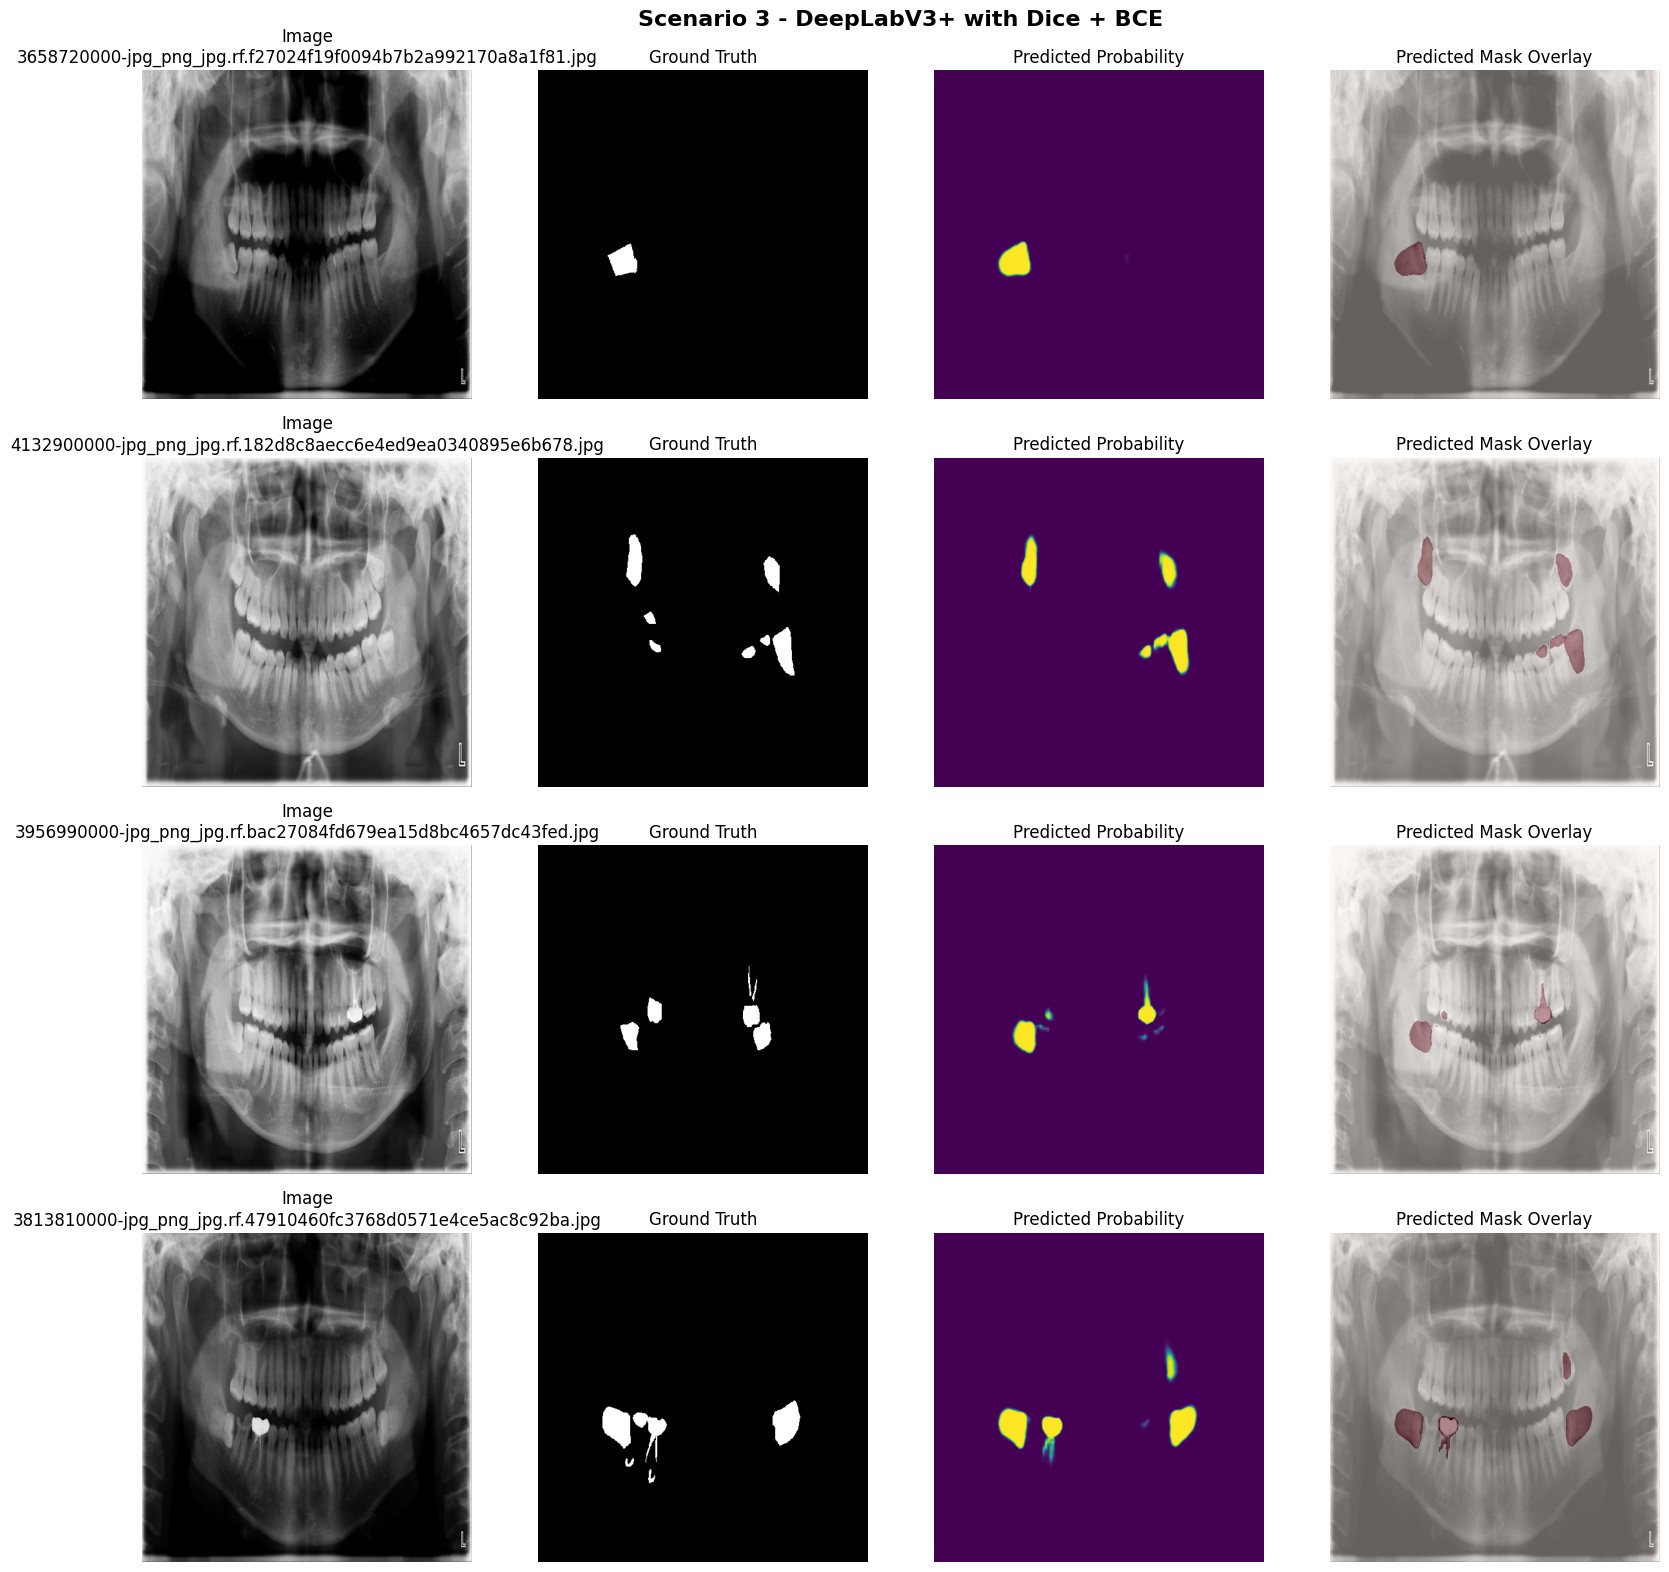

In [24]:
# Load best modified-loss model and evaluate on test
best_modified_model = build_model().to(device)
best_modified_model.load_state_dict(torch.load(modified_loss_result["best_model_path"], map_location=device))

modified_valid_metrics = evaluate_model(
    model=best_modified_model,
    loader=valid_loader,
    criterion=get_loss("dice_bce"),
    device=device,
    threshold=THRESHOLD,
    split_name="valid-modified",
)

modified_test_metrics = evaluate_model(
    model=best_modified_model,
    loader=test_loader,
    criterion=get_loss("dice_bce"),
    device=device,
    threshold=THRESHOLD,
    split_name="test-modified",
)

print("Modified loss - Validation metrics:")
print(pd.DataFrame([modified_valid_metrics]).round(4))

print("\nModified loss - Test metrics:")
print(pd.DataFrame([modified_test_metrics]).round(4))

visualize_predictions(
    model=best_modified_model,
    dataset=test_dataset,
    device=device,
    num_samples=4,
    threshold=THRESHOLD,
    title="Scenario 3 - DeepLabV3+ with Dice + BCE"
)

In [25]:
# Final comparison table
comparison_df = pd.DataFrame([
    {"scenario": "1_baseline_no_training", **baseline_test_metrics},
    {"scenario": "2_finetune_bce", **fine_tune_test_metrics},
    {"scenario": "3_modified_dice_bce", **modified_test_metrics},
]).round(4)

comparison_df

,scenario,iou,dice,precision,recall,accuracy,specificity,loss
0,1_baseline_no_training,0.0022,0.0044,0.0300,0.0024,0.9746,0.9981,0.6818
1,2_finetune_bce,0.5077,0.6735,0.7801,0.5925,0.9865,0.9960,0.0452
2,3_modified_dice_bce,0.5387,0.7002,0.7570,0.6513,0.9868,0.9949,0.1895


In [26]:
# Save comparison table
comparison_path = OUTPUT_DIR / "scenario_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved comparison table to:", comparison_path)

Saved comparison table to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/scenario_comparison.csv


In [27]:
import json
import shutil
from pathlib import Path
import torch

FINAL_SAVE_DIR = OUTPUT_DIR / "final_saved_models"
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving all scenario artifacts to:", FINAL_SAVE_DIR)

# Helper to safely convert metrics/config to JSON-serializable format
def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_serializable(v) for v in obj]
    elif isinstance(obj, Path):
        return str(obj)
    elif isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    else:
        return obj

# Shared config metadata
common_config = {
    "encoder_name": ENCODER_NAME,
    "encoder_weights": ENCODER_WEIGHTS,
    "in_channels": IN_CHANNELS,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "threshold": THRESHOLD,
    "device_used": str(device),
    "dataset_image_root": str(IMAGE_ROOT),
    "dataset_mask_root": str(MASK_ROOT),
}

# Scenario 1: Baseline (save base model as-is)
scenario1_dir = FINAL_SAVE_DIR / "scenario_1_baseline"
scenario1_dir.mkdir(parents=True, exist_ok=True)

scenario1_model_path = scenario1_dir / "baseline_model_state_dict.pth"
scenario1_meta_path  = scenario1_dir / "baseline_metadata.json"

torch.save({
    "scenario": "scenario_1_baseline_no_training",
    "model_state_dict": baseline_model.state_dict(),
    "model_class": "DeepLabV3Plus",
    "config": common_config,
    "valid_metrics": baseline_valid_metrics,
    "test_metrics": baseline_test_metrics,
}, scenario1_model_path)

with open(scenario1_meta_path, "w") as f:
    json.dump(to_serializable({
        "scenario": "scenario_1_baseline_no_training",
        "saved_weight_path": scenario1_model_path,
        "notes": "This is the raw pretrained/base model without task-specific training.",
        "config": common_config,
        "valid_metrics": baseline_valid_metrics,
        "test_metrics": baseline_test_metrics,
    }), f, indent=4)

print(f"[S1] Baseline model saved to: {scenario1_model_path}")
print(f"[S1] Metadata saved to:       {scenario1_meta_path}")

# Scenario 2: Fine-tuning (save best model)
scenario2_dir = FINAL_SAVE_DIR / "scenario_2_finetune_bce"
scenario2_dir.mkdir(parents=True, exist_ok=True)

scenario2_model_path = scenario2_dir / "best_finetune_model_state_dict.pth"
scenario2_meta_path  = scenario2_dir / "finetune_metadata.json"
scenario2_history_path = scenario2_dir / "finetune_history.csv"

# Copy the already-saved best model from training
if Path(fine_tune_result["best_model_path"]).exists():
    shutil.copy2(fine_tune_result["best_model_path"], scenario2_model_path)
else:
    # fallback: save directly from loaded best model
    torch.save({
        "model_state_dict": best_finetune_model.state_dict()
    }, scenario2_model_path)

# Save history again into the final folder
fine_tune_history.to_csv(scenario2_history_path, index=False)

with open(scenario2_meta_path, "w") as f:
    json.dump(to_serializable({
        "scenario": "scenario_2_finetune_bce",
        "saved_weight_path": scenario2_model_path,
        "original_best_model_path": fine_tune_result["best_model_path"],
        "history_path": scenario2_history_path,
        "best_valid_dice": fine_tune_result["best_valid_dice"],
        "config": {
            **common_config,
            "loss_name": "bce",
            "epochs": FINE_TUNE_EPOCHS,
            "learning_rate": FINE_TUNE_LR,
            "weight_decay": WEIGHT_DECAY,
        },
        "valid_metrics": fine_tune_valid_metrics,
        "test_metrics": fine_tune_test_metrics,
    }), f, indent=4)

print(f"[S2] Best fine-tuned model saved to: {scenario2_model_path}")
print(f"[S2] Metadata saved to:              {scenario2_meta_path}")
print(f"[S2] History saved to:               {scenario2_history_path}")

# Scenario 3: Modified loss (save best model)
scenario3_dir = FINAL_SAVE_DIR / "scenario_3_modified_dice_bce"
scenario3_dir.mkdir(parents=True, exist_ok=True)

scenario3_model_path = scenario3_dir / "best_modified_loss_model_state_dict.pth"
scenario3_meta_path  = scenario3_dir / "modified_loss_metadata.json"
scenario3_history_path = scenario3_dir / "modified_loss_history.csv"

# Copy the already-saved best model from training
if Path(modified_loss_result["best_model_path"]).exists():
    shutil.copy2(modified_loss_result["best_model_path"], scenario3_model_path)
else:
    # fallback: save directly from loaded best model
    torch.save({
        "model_state_dict": best_modified_model.state_dict()
    }, scenario3_model_path)

# Save history again into the final folder
modified_loss_history.to_csv(scenario3_history_path, index=False)

with open(scenario3_meta_path, "w") as f:
    json.dump(to_serializable({
        "scenario": "scenario_3_modified_dice_bce",
        "saved_weight_path": scenario3_model_path,
        "original_best_model_path": modified_loss_result["best_model_path"],
        "history_path": scenario3_history_path,
        "best_valid_dice": modified_loss_result["best_valid_dice"],
        "config": {
            **common_config,
            "loss_name": "dice_bce",
            "epochs": MOD_LOSS_EPOCHS,
            "learning_rate": MOD_LOSS_LR,
            "weight_decay": WEIGHT_DECAY,
        },
        "valid_metrics": modified_valid_metrics,
        "test_metrics": modified_test_metrics,
    }), f, indent=4)

print(f"[S3] Best modified-loss model saved to: {scenario3_model_path}")
print(f"[S3] Metadata saved to:                 {scenario3_meta_path}")
print(f"[S3] History saved to:                  {scenario3_history_path}")

# Save one summary file for all scenarios
summary_path = FINAL_SAVE_DIR / "all_scenarios_summary.json"

all_summary = {
    "scenario_1": {
        "model_path": scenario1_model_path,
        "metadata_path": scenario1_meta_path,
        "test_metrics": baseline_test_metrics,
    },
    "scenario_2": {
        "model_path": scenario2_model_path,
        "metadata_path": scenario2_meta_path,
        "history_path": scenario2_history_path,
        "best_valid_dice": fine_tune_result["best_valid_dice"],
        "test_metrics": fine_tune_test_metrics,
    },
    "scenario_3": {
        "model_path": scenario3_model_path,
        "metadata_path": scenario3_meta_path,
        "history_path": scenario3_history_path,
        "best_valid_dice": modified_loss_result["best_valid_dice"],
        "test_metrics": modified_test_metrics,
    },
}

with open(summary_path, "w") as f:
    json.dump(to_serializable(all_summary), f, indent=4)

print("\nAll scenario artifacts have been saved successfully.")
print("Summary file:", summary_path)

Saving all scenario artifacts to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models
[S1] Baseline model saved to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models/scenario_1_baseline/baseline_model_state_dict.pth
[S1] Metadata saved to:       /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models/scenario_1_baseline/baseline_metadata.json
[S2] Best fine-tuned model saved to: /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models/scenario_2_finetune_bce/best_finetune_model_state_dict.pth
[S2] Metadata saved to:              /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models/scenario_2_finetune_bce/finetune_metadata.json
[S2] History saved to:               /content/drive/MyDrive/Kebutuhan_NLP_X_DL_Kelompok_6/DL/DeepLabv3+/final_saved_models/scenario_2_finetune_bce/finetune_history.csv
[S3] Best modified-loss model saved

## Expected Interpretation

- **Scenario 1** will usually perform poorly because the segmentation decoder/head has not been trained on the dental masks.
- **Scenario 2** is your standard fine-tuning baseline.
- **Scenario 3** is the more segmentation-aware experiment and will often outperform plain BCE when the foreground area is relatively imbalanced.

If you want, you can later change the modified loss from:
- `dice_bce` → `tversky`
- or extend it to `focal + dice`